In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [3]:
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [5]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Accuracy: 1.00
Confusion Matrix:
 Predicted  Setosa  Versicolor  Virginica
Actual                                  
0              10           0          0
1               0           9          0
2               0           0         11


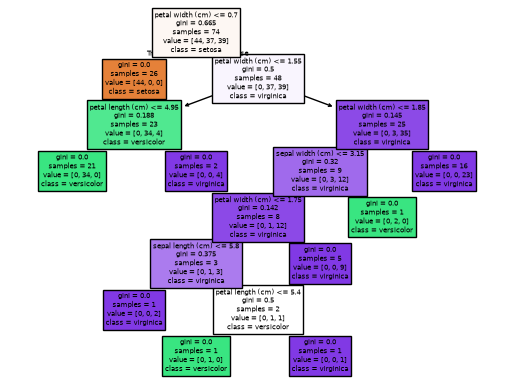

In [13]:
from sklearn.tree import plot_tree
def random_forest_classifier(df: pd.DataFrame, target: pd.Series):
    X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"Accuracy: {accuracy:.2f}")
    y_pred = model.predict(X_test)
    scatter = plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_pred, cmap='viridis', edgecolor='k', s=100)
    handles, _ = scatter.legend_elements()
    plt.legend(handles, ['Setosa', 'Versicolor', 'Virginica'], title="Classes")
    confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted']).rename(columns={0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})
    print("Confusion Matrix:\n", confusion_matrix)
    plot_tree(model.estimators_[0], feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
random_forest_classifier(df, iris.target)